# 10_08 "Do we order too much raw meat?" — a two-level simulation

**The company's original motivation** was: *"we order too much raw meat and then
have to throw it away."* This notebook answers that with a simulation, for the
biggest and most perishable cut family: **Hackfleisch/Mett** (Mettschulter +
beef trimmings in; minced products out; finished shelf life ≈ one day).

The insight from `10_06`/`10_07` is that "ordering" for counter products is two
decisions, and waste can come from either:

- **The order**: how much raw meat to request from the plant (per delivery, a
  few days ahead, at family level) — parameterised here by an order quantile
  `q`: how much safety stock above the expected need.
- **The production discipline**: what the counter does with what arrived.
  **Push** = process what was delivered, paced to be worked off by the next
  delivery ("the meat is here"). **Pull** = produce only what today's forecast
  justifies (the `τ*` rule from `10_06`) and let surplus raw wait, sealed, in
  the cold room.

We simulate a cold room per store, day by day, over the 20 evaluation weeks:
raw meat arrives per the ordering rule, is produced into counter goods per the
discipline, unsold finished product dies same-day, and raw packs die after
their shelf life. Every kg gets a price: finished waste costs the calculatory
product cost (`ESP`, `10_06`), raw waste costs the store's delivery-mix-weighted
plant price (per-article `ESP_KALK` from `artikel_preis_wgr_890_900.csv`
joined to the store's actual raw deliveries), unmet demand costs the lost
margin.

**Assumptions, stated up front**: raw-to-counter conversion factor 0.83 (the
family's observed in/out ratio from `10_07`, which implicitly includes the trim
inflow from other cuts); raw shelf life 10 days (vac-packed; a sensitivity
band is reported); lead time 3 days per the
company's order schedule, with order days falling on a Sunday moved to
Saturday (4-day lead); delivery weekdays per store read off the store's actual
delivery pattern; first two evaluation weeks are burn-in and
not scored; demand is independent of availability; salvage of finished goods
zero (as in `10_06`'s base case).

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.lightgbm import TWO_STAGE_QUANTILE_MODEL_NAME
from src.models.results import result_path

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns', 40)
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE, SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE, ORANGE, AQUA, GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#c3c2b7'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
})


def style_ax(ax, ygrid=True, xgrid=False):
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE)
    if ygrid:
        ax.grid(axis='y', color=GRID, linewidth=0.8)
    if xgrid:
        ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


F_RAW_PER_COUNTER = 0.83   # family in/out ratio from 10_07
RAW_SHELF_DAYS = 10        # vac-packed raw keeps ~10 days (sensitivity below)
LEAD_DAYS = 3              # order placed 3 days before arrival (Sunday order days shift to Saturday)
BURN_IN_DAYS = 14
VAT = 1.07

con = duckdb.connect()
con.execute('PRAGMA threads=4')


def is_hack_counter(name):
    n = name.lower()
    if any(k in n for k in ('frankreich', 'irland', 'spanien', 'iberico',
                            'neuseeland', 'lamm', 'kalb', 'hirsch',
                            'spanferkel', 'moorschwein', 'mettenden')):
        return False
    return any(k in n for k in ('hack', 'mett', 'tartar', 'tatar', 'burger',
                                'patty', 'pattie', 'lattenknaller'))


HACK_RAW_KEYS = ('mettschulter', 'abschnitte', 'schinkenmett', 'gehacktes',
                 'fleisch in stück', '80/20')

names_tx = con.execute('''
    SELECT ARTIKEL_ID, ANY_VALUE(ARTIKEL_BEZ) AS name
    FROM read_parquet(?) WHERE is_pseudo GROUP BY 1
''', [str(ROOT / 'data' / 'processed' / 'transactions_fixed' / 'transactions_year_*.parquet')]).fetchdf()
family_articles = names_tx[names_tx.name.map(is_hack_counter)].ARTIKEL_ID.tolist()
print(f'{len(family_articles)} counter articles in the Hackfleisch/Mett family')

con.execute('CREATE TEMP TABLE fam AS SELECT UNNEST(?::BIGINT[]) AS ARTIKEL_ID',
            [family_articles])

design = load_benchmark_design()
rows = con.execute('''
    SELECT r.ARTIKEL_ID::BIGINT AS ARTIKEL_ID, r.MARKT_ID::BIGINT AS MARKT_ID,
           CAST(r.period AS DATE) AS period,
           r.actual::DOUBLE AS actual, r.forecast::DOUBLE AS forecast,
           r.occurrence_probability::DOUBLE AS p_occ,
           r.positive_quantity_p10::DOUBLE AS p10,
           r.positive_quantity_p50::DOUBLE AS p50,
           r.positive_quantity_p90::DOUBLE AS p90
    FROM read_csv_auto(?) r JOIN fam USING (ARTIKEL_ID)
    WHERE r.is_active
''', [str(result_path(TWO_STAGE_QUANTILE_MODEL_NAME, design))]).fetchdf()

# prices -> per-row tau* and costs (same construction as 10_06, salvage 0)
con.register('lines', rows[['ARTIKEL_ID', 'MARKT_ID', 'period']].drop_duplicates())
prices = con.execute('''
    SELECT l.ARTIKEL_ID, l.MARKT_ID, l.period,
           AVG(p.ESP_KALK) AS esp, AVG(p.BRUTTOPREIS_EH) AS brutto
    FROM lines l JOIN read_csv_auto(?) p
      ON p.ARTIKEL_ID = l.ARTIKEL_ID AND p.MANDANT_ID = l.MARKT_ID // 10000
     AND l.period::DATE BETWEEN p.GUELTIG_VON_ARTIKEL_PREIS AND p.GUELTIG_BIS_ARTIKEL_PREIS
    WHERE p.ESP_KALK > 0.01 GROUP BY 1, 2, 3
''', [str(ROOT / 'data' / 'raw' / 'artikel_preis' / 'artikel_preis_wgr_890_900.csv')]).fetchdf()
rows = rows.merge(prices, on=['ARTIKEL_ID', 'MARKT_ID', 'period'], how='left')
for col in ('esp', 'brutto'):
    rows[col] = rows[col].fillna(rows.groupby('ARTIKEL_ID')[col].transform('median'))
rows['net'] = rows.brutto / VAT
rows['c_under'] = (rows.net - rows.esp).clip(lower=0)
rows['c_over'] = rows.esp
rows['tau_star'] = (rows.c_under / (rows.c_under + rows.c_over)).clip(0.05, 0.95)

p, p10, p50, p90 = rows.p_occ.values, rows.p10.values, rows.p50.values, rows.p90.values
u = np.clip((rows.tau_star.values - (1 - p)) / np.maximum(p, 1e-9), 0.0, 0.99)
q = np.where(u <= 0.1, u / 0.1 * p10,
    np.where(u <= 0.5, p10 + (u - 0.1) / 0.4 * (p50 - p10),
    np.where(u <= 0.9, p50 + (u - 0.5) / 0.4 * (p90 - p50),
             p90 + (u - 0.9) / 0.4 * (p90 - p50))))
rows['pull_qty'] = np.where(u <= 0, 0.0, q)

w = rows.forecast.clip(lower=0.01)
day = rows.assign(cu_w=rows.c_under * w, co_w=rows.c_over * w, w=w) \
    .groupby(['MARKT_ID', 'period']) \
    .agg(mu=('forecast', 'sum'), sales=('actual', 'sum'),
         pull=('pull_qty', 'sum'), cu_w=('cu_w', 'sum'),
         co_w=('co_w', 'sum'), w=('w', 'sum')).reset_index()
day['cu'] = day.cu_w / day.w
day['co'] = day.co_w / day.w

# raw-side facts from the receipts: price and per-store delivery weekdays
raw_we = con.execute(f'''
    SELECT CAST(w.EH_ARTIKEL_ID AS BIGINT) AS ARTIKEL_ID,
           CAST(w.MARKT_ID AS BIGINT) AS MARKT_ID, CAST(w.DATE AS DATE) AS d,
           CAST(w.WE_MENGE_VKE AS DOUBLE) AS kg, CAST(w.UMSATZ_EK_NETTO AS DOUBLE) AS ek
    FROM read_csv(?, all_varchar=true) w
    JOIN read_csv_auto(?) n ON CAST(n.EH_ARTIKEL_ID AS BIGINT) = CAST(w.EH_ARTIKEL_ID AS BIGINT)
    WHERE w.EH_WGR_LIEFERANT_ID IN ('890006780','890008845','890007073')
      AND ({' OR '.join("lower(n.ARTIKEL_BEZ) LIKE '%" + k + "%'" for k in HACK_RAW_KEYS)})
      AND CAST(w.WE_MENGE_VKE AS DOUBLE) > 0
''', [str(ROOT / 'data' / 'raw' / 'wareneingaenge_full' / 'wareneingänge_full.csv'),
      str(ROOT / 'data' / 'raw' / 'wareneingaenge_full' / 'lieferanten_89000.csv')]).fetchdf()

# price each delivered raw kg at its article's ESP on that day; a store's raw
# price is the delivery-mix-weighted mean over the trailing year of the eval window
con.register('raw_deliv', raw_we[raw_we.d >= pd.Timestamp('2025-07-01')])
raw_px = con.execute('''
    SELECT r.MARKT_ID, SUM(r.kg * px.esp) / SUM(r.kg) AS ek_raw
    FROM raw_deliv r
    JOIN (SELECT ARTIKEL_ID, MANDANT_ID, GUELTIG_VON_ARTIKEL_PREIS AS von,
                 GUELTIG_BIS_ARTIKEL_PREIS AS bis, AVG(ESP_KALK) AS esp
          FROM read_csv_auto(?) WHERE ESP_KALK > 0.01
          GROUP BY 1, 2, 3, 4) px
      ON px.ARTIKEL_ID = r.ARTIKEL_ID AND px.MANDANT_ID = r.MARKT_ID // 10000
     AND r.d BETWEEN px.von AND px.bis
    GROUP BY 1
''', [str(ROOT / 'data' / 'raw' / 'artikel_preis' / 'artikel_preis_wgr_890_900.csv')]).fetchdf()
EK_RAW_STORE = dict(zip(raw_px.MARKT_ID, raw_px.ek_raw))
EK_RAW = float(np.average(raw_px.ek_raw))

dw = raw_we.assign(dow=raw_we.d.dt.dayofweek, wk=raw_we.d.dt.to_period('W'))
n_weeks_store = dw.groupby('MARKT_ID').wk.nunique()
dow_freq = (dw.drop_duplicates(['MARKT_ID', 'd']).groupby(['MARKT_ID', 'dow']).size()
            .div(n_weeks_store, level='MARKT_ID'))
DELIVERY_DOWS = {m: set(g[g >= 0.4].index.get_level_values('dow'))
                 for m, g in dow_freq.groupby('MARKT_ID')}
DEFAULT_DOWS = {0, 2, 4}

# trailing dispersion of window demand: weekly family sales history per store
hist = con.execute('''
    SELECT t.MARKT_ID, CAST(t.DATE AS DATE) AS d, SUM(t.ABVERKAUFTE_MENGE_KG) AS kg
    FROM read_parquet(?) t JOIN fam USING (ARTIKEL_ID)
    WHERE t.is_pseudo AND t.is_active GROUP BY 1, 2
''', [str(ROOT / 'data' / 'processed' / 'transactions_fixed' / 'transactions_year_*.parquet')]).fetchdf()
hist['week'] = hist.d - pd.to_timedelta(hist.d.dt.dayofweek, unit='D')
wk_hist = hist.groupby(['MARKT_ID', 'week']).kg.sum().rename('kg').reset_index()
wk_hist['sigma8'] = wk_hist.groupby('MARKT_ID').kg.transform(
    lambda s: s.rolling(8, min_periods=4).std().shift(1))

print(f'{day.MARKT_ID.nunique()} stores | eval days {day.period.min().date()} '
      f'-> {day.period.max().date()} | family demand {day.sales.sum()/1000:,.0f} t')
print(f'raw price, delivery-mix-weighted ESP per store: mean {EK_RAW:.2f} eur/kg, '
      f'P10 {raw_px.ek_raw.quantile(.1):.2f}, P90 {raw_px.ek_raw.quantile(.9):.2f} '
      f'({len(EK_RAW_STORE)} stores priced)')

19 counter articles in the Hackfleisch/Mett family


190 stores | eval days 2026-03-02 -> 2026-07-18 | family demand 705 t
raw price, delivery-mix-weighted ESP per store: mean 5.43 eur/kg, P10 4.35, P90 6.32 (195 stores priced)


## The simulation

Per store, per calendar day of the evaluation window:

1. **Arrivals**: on the store's delivery weekdays, the raw order placed 2 days
   earlier arrives into the cold room (FIFO by age).
2. **Ordering rule** (decided at order time, for the window until the next
   delivery): order up to `0.83 × (forecast window demand + z_q × σ)`, where
   `σ` is the store's trailing 8-week variability, minus what is already in
   the room or underway. `q` is the dial we sweep.
3. **Production**: *push* produces the cold-room stock paced to be gone by the
   next delivery; *pull* produces the `τ*` quantities from `10_06`. Neither
   can produce more than the raw on hand.
4. **Accounting**: finished production beyond the day's sales dies at product
   cost (minced goods keep ~a day); demand beyond production is lost margin;
   raw packs older than 10 days die at the plant price.

The first two weeks initialise the cold room and are not scored.

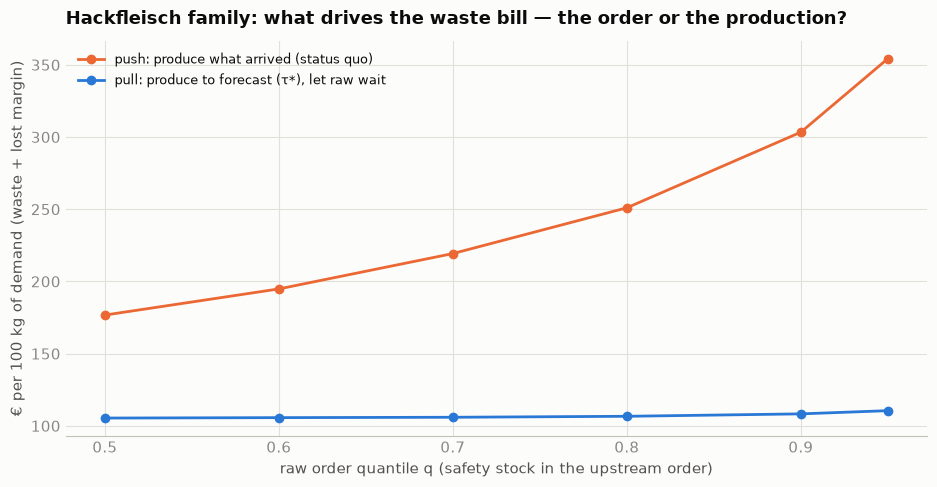

order quantile,discipline,finished waste kg/100,raw waste kg/100,unmet kg/100,eur finished waste,eur lost margin,eur raw waste,eur total /100kg
0.600000,push,20.64,0.00,12.76,136.65,58.16,0.00,194.80
0.600000,pull,6.40,0.04,14.85,39.59,65.86,0.22,105.68
0.900000,push,41.31,0.00,6.41,274.08,29.28,0.00,303.36
0.900000,pull,6.40,0.49,14.85,39.57,65.86,2.85,108.28


In [2]:
Z = {0.50: 0.0, 0.60: 0.25, 0.70: 0.52, 0.80: 0.84, 0.90: 1.28, 0.95: 1.64}


def simulate(store_frame, dows, sigma_lookup, q, discipline,
             shelf=RAW_SHELF_DAYS, f=F_RAW_PER_COUNTER, ek_raw=None):
    ek_raw = EK_RAW if ek_raw is None else ek_raw
    days = store_frame.period.tolist()
    mu = store_frame.mu.values
    sales = store_frame.sales.values
    pull = store_frame.pull.values
    cu, co = store_frame.cu.values, store_frame.co.values
    n = len(days)
    is_delivery = np.array([d.dayofweek in dows for d in days])
    next_del = np.full(n, n)
    nxt = n
    for i in range(n - 1, -1, -1):
        next_del[i] = nxt
        if is_delivery[i]:
            nxt = i

    order_for = {}                  # order day -> arrival days (lead 3, Sunday -> Saturday)
    for a in range(n):
        if is_delivery[a]:
            od = a - LEAD_DAYS
            if od >= 0 and days[od].dayofweek == 6:
                od -= 1
            if od >= 0:
                order_for.setdefault(od, []).append(a)

    stock = []                      # list of [age, kg], FIFO
    start = f * mu[:3].sum()
    if start > 0:
        stock.append([0, start])
    pending = {}                    # arrival index -> kg
    res = np.zeros(4)               # finished_waste, unmet, raw_waste, demand (scored)
    eur = np.zeros(3)               # finished€, lost margin€, raw€

    for t in range(n):
        arr = pending.pop(t, 0.0)
        if arr > 0:
            stock.append([0, arr])
        # place orders for deliveries whose order day is today
        for a in order_for.get(t, []):
            w_end = next_del[a] if next_del[a] < n else n
            mu_win = mu[a:w_end].sum()
            sigma = sigma_lookup(days[t]) * np.sqrt(max(w_end - a, 1) / 6.0)
            target = f * (mu_win + Z[q] * sigma)
            onhand = sum(kg for _, kg in stock) + sum(pending.values())
            projected = onhand - f * mu[t:a].sum()
            order = max(target - projected, 0.0)
            if order > 0:
                pending[a] = pending.get(a, 0.0) + order
        # production
        raw_avail = sum(kg for _, kg in stock)
        if mu[t] > 0 or sales[t] > 0:
            if discipline == 'push':
                horizon = max(next_del[t] - t, 1)
                desired = raw_avail / f / horizon
            else:
                desired = pull[t]
        else:
            desired = 0.0
        prod = min(desired, raw_avail / f)
        need = prod * f
        for pack in stock:
            take = min(pack[1], need)
            pack[1] -= take
            need -= take
            if need <= 0:
                break
        stock = [pk for pk in stock if pk[1] > 1e-9]
        # aging and expiry
        expired = 0.0
        for pack in stock:
            pack[0] += 1
        expired = sum(kg for age, kg in stock if age > shelf)
        stock = [pk for pk in stock if pk[0] <= shelf]
        # scoring
        if t >= BURN_IN_DAYS:
            fw = max(prod - sales[t], 0.0)
            un = max(sales[t] - prod, 0.0)
            res += [fw, un, expired, sales[t]]
            eur += [fw * co[t], un * cu[t], expired * ek_raw]
    return res, eur


day = day.sort_values(['MARKT_ID', 'period'])
stores = []
for markt, g in day.groupby('MARKT_ID'):
    sig = wk_hist[wk_hist.MARKT_ID == markt].set_index('week').sigma8
    med = sig.median() if sig.notna().any() else g.sales.mean()

    def lookup(d, sig=sig, med=med, g=g):
        wk = (d - pd.Timedelta(days=d.dayofweek)).normalize()
        v = sig.get(wk, np.nan)
        return v if np.isfinite(v) else (med if np.isfinite(med) else 0.5 * g.mu.mean())
    stores.append((markt, g.reset_index(drop=True),
                   DELIVERY_DOWS.get(markt, DEFAULT_DOWS) or DEFAULT_DOWS, lookup))

records = []
for q_ord in Z:
    for disc in ('push', 'pull'):
        tot_res, tot_eur = np.zeros(4), np.zeros(3)
        for markt, g, dows, lookup in stores:
            r, e = simulate(g, dows, lookup, q_ord, disc,
                            ek_raw=EK_RAW_STORE.get(markt))
            tot_res += r
            tot_eur += e
        fw, un, rw, dem = tot_res
        records.append({
            'order quantile': q_ord, 'discipline': disc,
            'finished waste kg/100': fw / dem * 100,
            'raw waste kg/100': rw / dem * 100,
            'unmet kg/100': un / dem * 100,
            'eur finished waste': tot_eur[0] / dem * 100,
            'eur lost margin': tot_eur[1] / dem * 100,
            'eur raw waste': tot_eur[2] / dem * 100,
            'eur total /100kg': tot_eur.sum() / dem * 100,
        })
sim = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(9.5, 5))
for disc, color, label in (('push', ORANGE, 'push: produce what arrived (status quo)'),
                           ('pull', BLUE, 'pull: produce to forecast (τ*), let raw wait')):
    s = sim[sim.discipline == disc]
    ax.plot(s['order quantile'], s['eur total /100kg'], marker='o',
            color=color, linewidth=2, label=label)
style_ax(ax, xgrid=True)
ax.set_xlabel('raw order quantile q (safety stock in the upstream order)')
ax.set_ylabel('€ per 100 kg of demand (waste + lost margin)')
ax.set_title('Hackfleisch family: what drives the waste bill — the order '
             'or the production?', pad=12)
ax.legend(frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()

show = sim[sim['order quantile'].isin([0.6, 0.9])].copy()
display(show.style.format({c: '{:.2f}' for c in show.columns[2:]}).hide(axis='index'))

**Reading the result.** The two curves answer the company's question almost by
themselves:

- **Under push, the order quantile is everything.** Ordering at P60 costs 195 €
  per 100 kg of demand; at P90 it costs 303 €, of which 274 € is finished-goods
  waste (41 kg of minced product per 100 kg demanded). And note the raw-waste
  column: **zero**. Exactly as the write-off data showed (raw spoilage ≈
  0.02%), a push counter never throws away raw meat — it faithfully converts
  every over-ordered kg into counter product first, and the waste appears one
  stage later. *"We order too much raw meat and throw it away"* is true in
  substance, but what lands in the bin is Hackfleisch.
- **Under pull, the order quantile almost stops mattering**: 105.7 € at P60 vs
  108.3 € at P90 — a 2.6 € difference where push showed 109 €. Surplus raw
  waits sealed in the cold room, next orders shrink, and even generous P90
  ordering produces only 0.5 kg of expired raw per 100 kg demanded — costed at
  each store's own delivery-mix price (4.35–6.32 €/kg across stores, mean
  5.43, from the per-article plant `ESP_KALK`). The safety stock becomes
  nearly free.
- **The disciplines differ by 89–195 € per 100 kg** — an order of magnitude
  more than any ordering-rule refinement in `10_06` (where the best rule beat
  the status quo by ~6 €). The production decision, not the order, owns the
  waste bill.
- Pull accepts more unmet demand (14.9 vs 6.4–12.8 kg/100) — that is `τ*`
  economics from `10_06`: at ~50% cost share, chasing the last service points
  costs more in waste than it earns. A push counter at P90 buys its higher
  fill rate with ~6× the waste.

The shelf-life sensitivity confirms the mechanism: varying raw shelf life from
7 to 14 days moves pull by a few euros and push not at all — push never keeps
raw long enough for expiry to matter.

In [3]:
# sensitivity: raw shelf life 7 vs 14 days, at the four corner policies
sens = []
for shelf in (7, 10, 14):
    for q_ord in (0.6, 0.9):
        for disc in ('push', 'pull'):
            tot_res, tot_eur = np.zeros(4), np.zeros(3)
            for markt, g, dows, lookup in stores:
                r, e = simulate(g, dows, lookup, q_ord, disc, shelf=shelf,
                                ek_raw=EK_RAW_STORE.get(markt))
                tot_res += r
                tot_eur += e
            sens.append({'shelf days': shelf, 'order q': q_ord, 'discipline': disc,
                         'eur total /100kg': tot_eur.sum() / tot_res[3] * 100})
sens = pd.DataFrame(sens).pivot_table(index=['discipline', 'order q'],
                                      columns='shelf days',
                                      values='eur total /100kg')
display(sens.style.format('{:.2f}'))

## Conclusions — the answer to the original question

**"Do we order too much raw meat?" — Yes at P90-style service levels, but that
is the smaller half of the problem.** The simulation separates the two levers
for the Hackfleisch/Mett family (190 stores, 20 evaluation weeks, 705 t of
demand, 3-day order lead per the company's schedule):

1. **If production tracks deliveries (push — the behaviour the company
   describes), waste is dominated by the order level**: cutting the order
   quantile from P90 to P60 saves ~109 € per 100 kg. This is the lever the
   company's question points at, and it is real.
2. **But changing the production discipline is worth more at every point**:
   at *any* order quantile, producing to the demand forecast (`τ*` from
   `10_06`) instead of to the delivery cuts the total bill by half or more
   (303→108 € at P90; 195→106 € at P60). Once production is decoupled from
   deliveries, the order quantile becomes almost irrelevant (2.6 € between P60
   and P90) — generous ordering is fine *if the counter stops processing it
   on arrival*.
3. **The raw-waste paradox resolves quantitatively**: booked raw spoilage is
   ~0.02% in reality and ~0 in the push simulation — because a push counter
   converts surplus raw into counter goods before it can expire. The company's
   waste is real but it is *manufactured* waste; attacking the raw order alone
   treats the symptom.

**Recommendation as the thesis states it**: order the family generously enough
to never constrain the counter (even P90 is cheap under pull), and let the
daily `τ*` rule — fed by the forecast model of this thesis — decide what gets
produced. The forecasting system's value is not a better raw order; it is the
licence to stop producing to stock.

**Limitations**: one family (the biggest and most perishable; families with
longer finished shelf life will show a smaller push–pull gap, since same-day
death of finished goods penalises push hardest); production and demand matched
at family level, so producing the wrong *article* within the family is not
penalised (this flatters both disciplines equally); delivery weekdays are the
store's observed pattern, lead time 3 days (Sunday order days shifted to
Saturday) per the company's schedule — the raw plants' own tour plan visibly
differs from the FCM schedule (Mon/Wed/Fri-dominant, Tuesday quiet); the
safety-stock σ is trailing demand dispersion rather than forecast-residual
dispersion (residuals exist only inside the evaluation window), which if
anything makes orders too generous — a bias *against* the pull result; demand
independent of availability; costs as in `10_06` (salvage 0 — any markdown
recovery shrinks all waste numbers proportionally, not the ranking).